# Análisis de Rentabilidad de Servicios de Jardinería (Primavera)

Este proyecto analiza diferentes tipos de trabajos de jardinería para identificar cuáles generan más ganancia y cuáles aprovechan mejor el tiempo de trabajo.

El objetivo es ayudar a mejorar decisiones de precios, servicios y eficiencia en el negocio.

## Carga de Datos

Se carga el conjunto de datos con diferentes trabajos de jardinería, incluyendo precios, costos y horas trabajadas.

In [36]:
import pandas as pd

pd.set_option('display.max_rows', None)

df = pd.read_csv("trabajos_jardineria.csv", encoding="latin1")

df

,ID_Trabajo,Tipo_Trabajo,Horas_Trabajadas,Precio_Cobrado,Costo_Material,Costo_Mano_de_Obra,Costo_Total,Ganancia,Ganancia_por_Hora
0,1,Corte de Césped,1.5,60,10,30,NaN,NaN,NaN
1,2,Limpieza de Primavera,4.0,290,50,90,NaN,NaN,NaN
2,3,Instalación de Mulch,4.5,420,140,85,NaN,NaN,NaN
3,4,Recorte de Arbustos,2.0,150,20,50,NaN,NaN,NaN
4,5,Aplicación de Fertilizante,1.5,115,40,30,NaN,NaN,NaN
5,6,Control de Maleza,2.0,135,35,45,NaN,NaN,NaN
6,7,Siembra de Césped (Resiembra),3.0,220,60,70,NaN,NaN,NaN
7,8,Preparación de Jardín,3.5,275,50,80,NaN,NaN,NaN
8,9,Plantación de Flores,2.5,200,80,60,NaN,NaN,NaN
9,10,Trabajo de Árboles Pequeños,4.0,480,110,95,NaN,NaN,NaN


## Cálculo de Ganancia

En esta sección se calculan métricas clave:

- Costo total del trabajo  
- Ganancia total  
- Ganancia por hora  

Estas métricas permiten evaluar qué trabajos son más rentables.

In [37]:
df["Costo_Total"] = df["Costo_Material"] + df["Costo_Mano_de_Obra"]
df["Ganancia"] = df["Precio_Cobrado"] - df["Costo_Total"]
df["Ganancia_por_Hora"] = (df["Ganancia"] / df["Horas_Trabajadas"]).round(2)

df

,ID_Trabajo,Tipo_Trabajo,Horas_Trabajadas,Precio_Cobrado,Costo_Material,Costo_Mano_de_Obra,Costo_Total,Ganancia,Ganancia_por_Hora
0,1,Corte de Césped,1.5,60,10,30,40,20,13.33
1,2,Limpieza de Primavera,4.0,290,50,90,140,150,37.50
2,3,Instalación de Mulch,4.5,420,140,85,225,195,43.33
3,4,Recorte de Arbustos,2.0,150,20,50,70,80,40.00
4,5,Aplicación de Fertilizante,1.5,115,40,30,70,45,30.00
5,6,Control de Maleza,2.0,135,35,45,80,55,27.50
6,7,Siembra de Césped (Resiembra),3.0,220,60,70,130,90,30.00
7,8,Preparación de Jardín,3.5,275,50,80,130,145,41.43
8,9,Plantación de Flores,2.5,200,80,60,140,60,24.00
9,10,Trabajo de Árboles Pequeños,4.0,480,110,95,205,275,68.75


## Análisis por Tipo de Trabajo

Aquí agrupamos los trabajos por tipo de servicio para entender cuáles son los más rentables en promedio.

Esto permite identificar qué servicios generan más dinero por hora.

In [38]:
df_grouped = df.groupby("Tipo_Trabajo").agg({
    "Ganancia": "mean",
    "Ganancia_por_Hora": "mean",
    "Precio_Cobrado": "mean",
    "Horas_Trabajadas": "mean"
}).round(2)

df_grouped

,Ganancia,Ganancia_por_Hora,Precio_Cobrado,Horas_Trabajadas
Tipo_Trabajo,,,,
Aplicación de Fertilizante,45.0,30.00,115.0,1.50
Control de Maleza,60.0,26.75,147.5,2.25
Corte de Césped,24.0,13.66,67.5,1.75
Instalación de Césped (Sod),360.0,60.00,750.0,6.00
Instalación de Mulch,185.0,46.66,390.0,4.00
Limpieza de Primavera,165.0,36.75,320.0,4.50
Plantación de Flores,60.0,24.00,200.0,2.50
Preparación de Jardín,145.0,41.43,275.0,3.50
Recorte de Arbustos,80.0,40.00,150.0,2.00


In [39]:
df_grouped.sort_values(by="Ganancia_por_Hora", ascending=False)

,Ganancia,Ganancia_por_Hora,Precio_Cobrado,Horas_Trabajadas
Tipo_Trabajo,,,,
Trabajo de Árboles Pequeños,275.0,68.75,480.0,4.00
Instalación de Césped (Sod),360.0,60.00,750.0,6.00
Instalación de Mulch,185.0,46.66,390.0,4.00
Preparación de Jardín,145.0,41.43,275.0,3.50
Recorte de Arbustos,80.0,40.00,150.0,2.00
Limpieza de Primavera,165.0,36.75,320.0,4.50
Aplicación de Fertilizante,45.0,30.00,115.0,1.50
Siembra de Césped (Resiembra),90.0,30.00,220.0,3.00
Control de Maleza,60.0,26.75,147.5,2.25


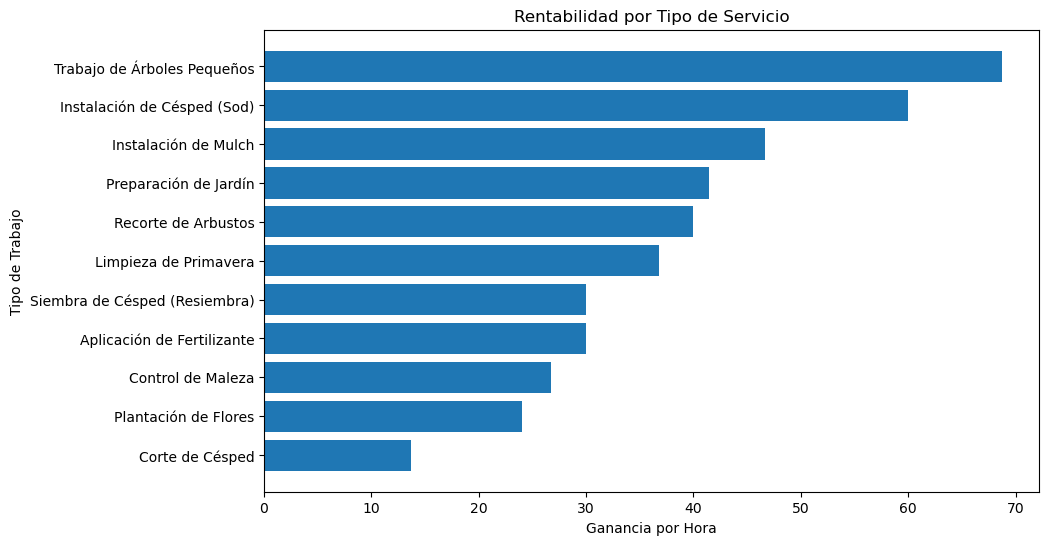

In [40]:
import matplotlib.pyplot as plt

df_sorted = df_grouped.sort_values(by="Ganancia_por_Hora", ascending=True)

plt.figure(figsize=(10,6))  # ← this is the ONLY upgrade
plt.barh(df_sorted.index, df_sorted["Ganancia_por_Hora"])

plt.xlabel("Ganancia por Hora")
plt.ylabel("Tipo de Trabajo")
plt.title("Rentabilidad por Tipo de Servicio")

plt.show()

## Visualización de Rentabilidad

A continuación se muestra una comparación de la ganancia por hora para cada tipo de trabajo.

Esta visualización permite identificar rápidamente cuáles servicios son más rentables.

## Conclusiones

- Los trabajos de árboles pequeños generan la mayor ganancia por hora  
- La instalación de césped (sod) también muestra alta rentabilidad  
- Los trabajos de mulch son consistentes y rentables  
- El corte de césped genera ingresos constantes, pero menor ganancia por hora  

Estos resultados están basados en el análisis de costos, precios y tiempo de trabajo de cada servicio.
## Recomendación

Enfocarse más en servicios de alta rentabilidad y optimizar los trabajos de menor ganancia puede aumentar significativamente las ganancias del negocio.

También se recomienda revisar los precios de servicios con baja ganancia por hora para mejorar su rentabilidad.